# 03 · Text Similarity — Captions Across Personas

For each image, multiple persona-driven annotators produced a caption.
This notebook measures **how similar those captions are** using sentence-level cosine similarity.

**Research question**: How much do personas converge (or diverge) in the way they describe the same urban scene? Which persona groups agree least?

**Method**: Encode all captions with `sentence-transformers/all-MiniLM-L6-v2`, then compute pairwise cosine similarity among captions for the same `image_id`. Summarize per-image and per-persona-pair.

In [1]:
import sys
sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
from itertools import combinations
from scipy.stats import mannwhitneyu

from src.config import FIGURES, OUTPUTS, FONT_SCALE, SENT_COLORS, SENT_COLORS_3
from src.data_loading import load_annotations, parse_demographics, create_profiles
from src.embeddings import load_or_encode_with_ids
from src.similarity import (
    compute_per_image_similarity, compute_per_persona_similarity,
    compute_within_cross_similarity, compute_profile_coherence,
)

MUTED = sns.color_palette("muted")
sns.set_theme(style="whitegrid", font_scale=FONT_SCALE)
plt.rcParams["figure.dpi"] = 150

FIGURES.mkdir(exist_ok=True)
OUTPUTS.mkdir(exist_ok=True)

df = load_annotations()
df = parse_demographics(df)
df = create_profiles(df)
print(f"Records: {len(df):,} | Images: {df['image_id'].nunique():,} | Personas: {df['persona_id'].nunique():,}")

Records: 59,708 | Images: 50 | Personas: 1,200


## 1 · Encode captions with SentenceTransformer

In [2]:
EMBED_CACHE = OUTPUTS / "caption_embeddings.npy"
ID_CACHE    = OUTPUTS / "caption_embeddings_ids.csv"

cap_embs, cap_idx = load_or_encode_with_ids(df, "caption", EMBED_CACHE, ID_CACHE)
print(f"Caption embeddings: {cap_embs.shape}")

Caption embeddings: (59708, 384)


## 2 · Per-image mean cosine similarity

In [3]:
SIMILARITY_CACHE = OUTPUTS / "per_image_cosine_similarity.csv"

sim_df = compute_per_image_similarity(cap_embs, df, cap_idx, SIMILARITY_CACHE)
print(f"Per-image caption similarity: {len(sim_df):,} images")
sim_df.head()

Per-image caption similarity: 50 images


,image_id,mean_sim,std_sim,min_sim,max_sim,n_personas
0,102tapSsNubXllWzP7asAW-qwMJApiWt6,0.944788,0.062142,0.088832,1.000001,1200
1,103V6ocF--_BPMnZoK9eUxTWbIZG2QsHG,0.734337,0.118839,-0.021664,1.000001,1200
2,10ha6FXS8e5O7LoMJMasGsqRPE_9V8tk4,0.830848,0.088102,0.319302,1.000001,1200
3,11DOuFmByYWPoQc2QyFxzxcb1da83nIqF,0.835903,0.114348,0.053536,1.000001,1200
4,135hGJxVBbYi9bnQervsmqZcCc4_Fn1fO,0.906490,0.074412,0.007529,1.000001,1200


## 8 · Justification text similarity (per image)

Mirrors the caption analysis of sections 2–6, applied to *justification* embeddings.
Since justifications are written in the persona's own voice, we expect lower convergence
than captions (which are instructed to be objective).

In [4]:
JUST_EMBED_CACHE = OUTPUTS / "justification_embeddings.npy"
JUST_SIM_CACHE   = OUTPUTS / "per_image_just_similarity.csv"

just_embs, just_idx = load_or_encode_with_ids(df, "justification", JUST_EMBED_CACHE, ID_CACHE)
just_sim_df_raw = compute_per_image_similarity(just_embs, df, just_idx, JUST_SIM_CACHE)
# rename columns to match downstream expectations
just_sim_df = just_sim_df_raw.rename(columns={
    "mean_sim": "mean_just_sim",
    "std_sim":  "std_just_sim",
    "min_sim":  "min_just_sim",
    "max_sim":  "max_just_sim",
})
print(f"Justification similarity: {len(just_sim_df):,} images")
just_sim_df.head()

Justification similarity: 50 images


,image_id,mean_just_sim,std_just_sim,min_just_sim,max_just_sim,n_personas
0,102tapSsNubXllWzP7asAW-qwMJApiWt6,0.587392,0.126061,-0.029784,1.000001,1200
1,103V6ocF--_BPMnZoK9eUxTWbIZG2QsHG,0.487179,0.146776,-0.035707,1.000001,1200
2,10ha6FXS8e5O7LoMJMasGsqRPE_9V8tk4,0.624235,0.116041,-0.007117,1.000001,1200
3,11DOuFmByYWPoQc2QyFxzxcb1da83nIqF,0.539765,0.135298,-0.015862,1.000001,1200
4,135hGJxVBbYi9bnQervsmqZcCc4_Fn1fO,0.547866,0.144818,-0.032838,1.000001,1200


## 9 · Within-persona vs. cross-persona text similarity

**Research question (Thiago):** Do agents with the *same* persona profile
produce more similar captions and justifications than agents with *different* profiles?

For each demographic dimension (gender, economic status, political spectrum, personality)
we split all pairwise similarities per image into *within-group* (same attribute level)
and *cross-group* (different attribute level) pairs, then compare their distributions.

This mirrors the UrbCom convergence structure but applied to text descriptions
rather than sentiment labels.

In [5]:
# Demographics and profiles are already parsed at load time (cell 1).
# demo_cols are available via df columns.
demo_cols = ["gender", "economic_status", "political_spectrum", "personality"]
print(f"Profile columns: {demo_cols}")
print(f"Unique profiles: {df['profile'].nunique()}")
df[demo_cols + ['profile']].head(3)

Profile columns: ['gender', 'economic_status', 'political_spectrum', 'personality']
Unique profiles: 24


,gender,economic_status,political_spectrum,personality,profile
0,Female,Low income,Conservative,Pragmatic,Female / Low income / Conservative / Pragmatic
1,Female,Low income,Conservative,Pragmatic,Female / Low income / Conservative / Pragmatic
2,Female,Low income,Conservative,Pragmatic,Female / Low income / Conservative / Pragmatic


In [6]:
WITHIN_CROSS_CACHE = OUTPUTS / "within_cross_persona_sim.csv"

wc_df = compute_within_cross_similarity(
    df, cap_embs, just_embs, cap_idx,
    cache_path=WITHIN_CROSS_CACHE,
)
print(f"Within/cross similarity: {len(wc_df):,} rows")
wc_df.head()

Within/cross similarity: 400 rows


,image_id,dimension,modality,within_mean,cross_mean
0,102tapSsNubXllWzP7asAW-qwMJApiWt6,gender,caption,0.945092,0.944484
1,102tapSsNubXllWzP7asAW-qwMJApiWt6,gender,justification,0.588298,0.586488
2,102tapSsNubXllWzP7asAW-qwMJApiWt6,economic_status,caption,0.945442,0.944134
3,102tapSsNubXllWzP7asAW-qwMJApiWt6,economic_status,justification,0.609365,0.565457
4,102tapSsNubXllWzP7asAW-qwMJApiWt6,political_spectrum,caption,0.945251,0.944325


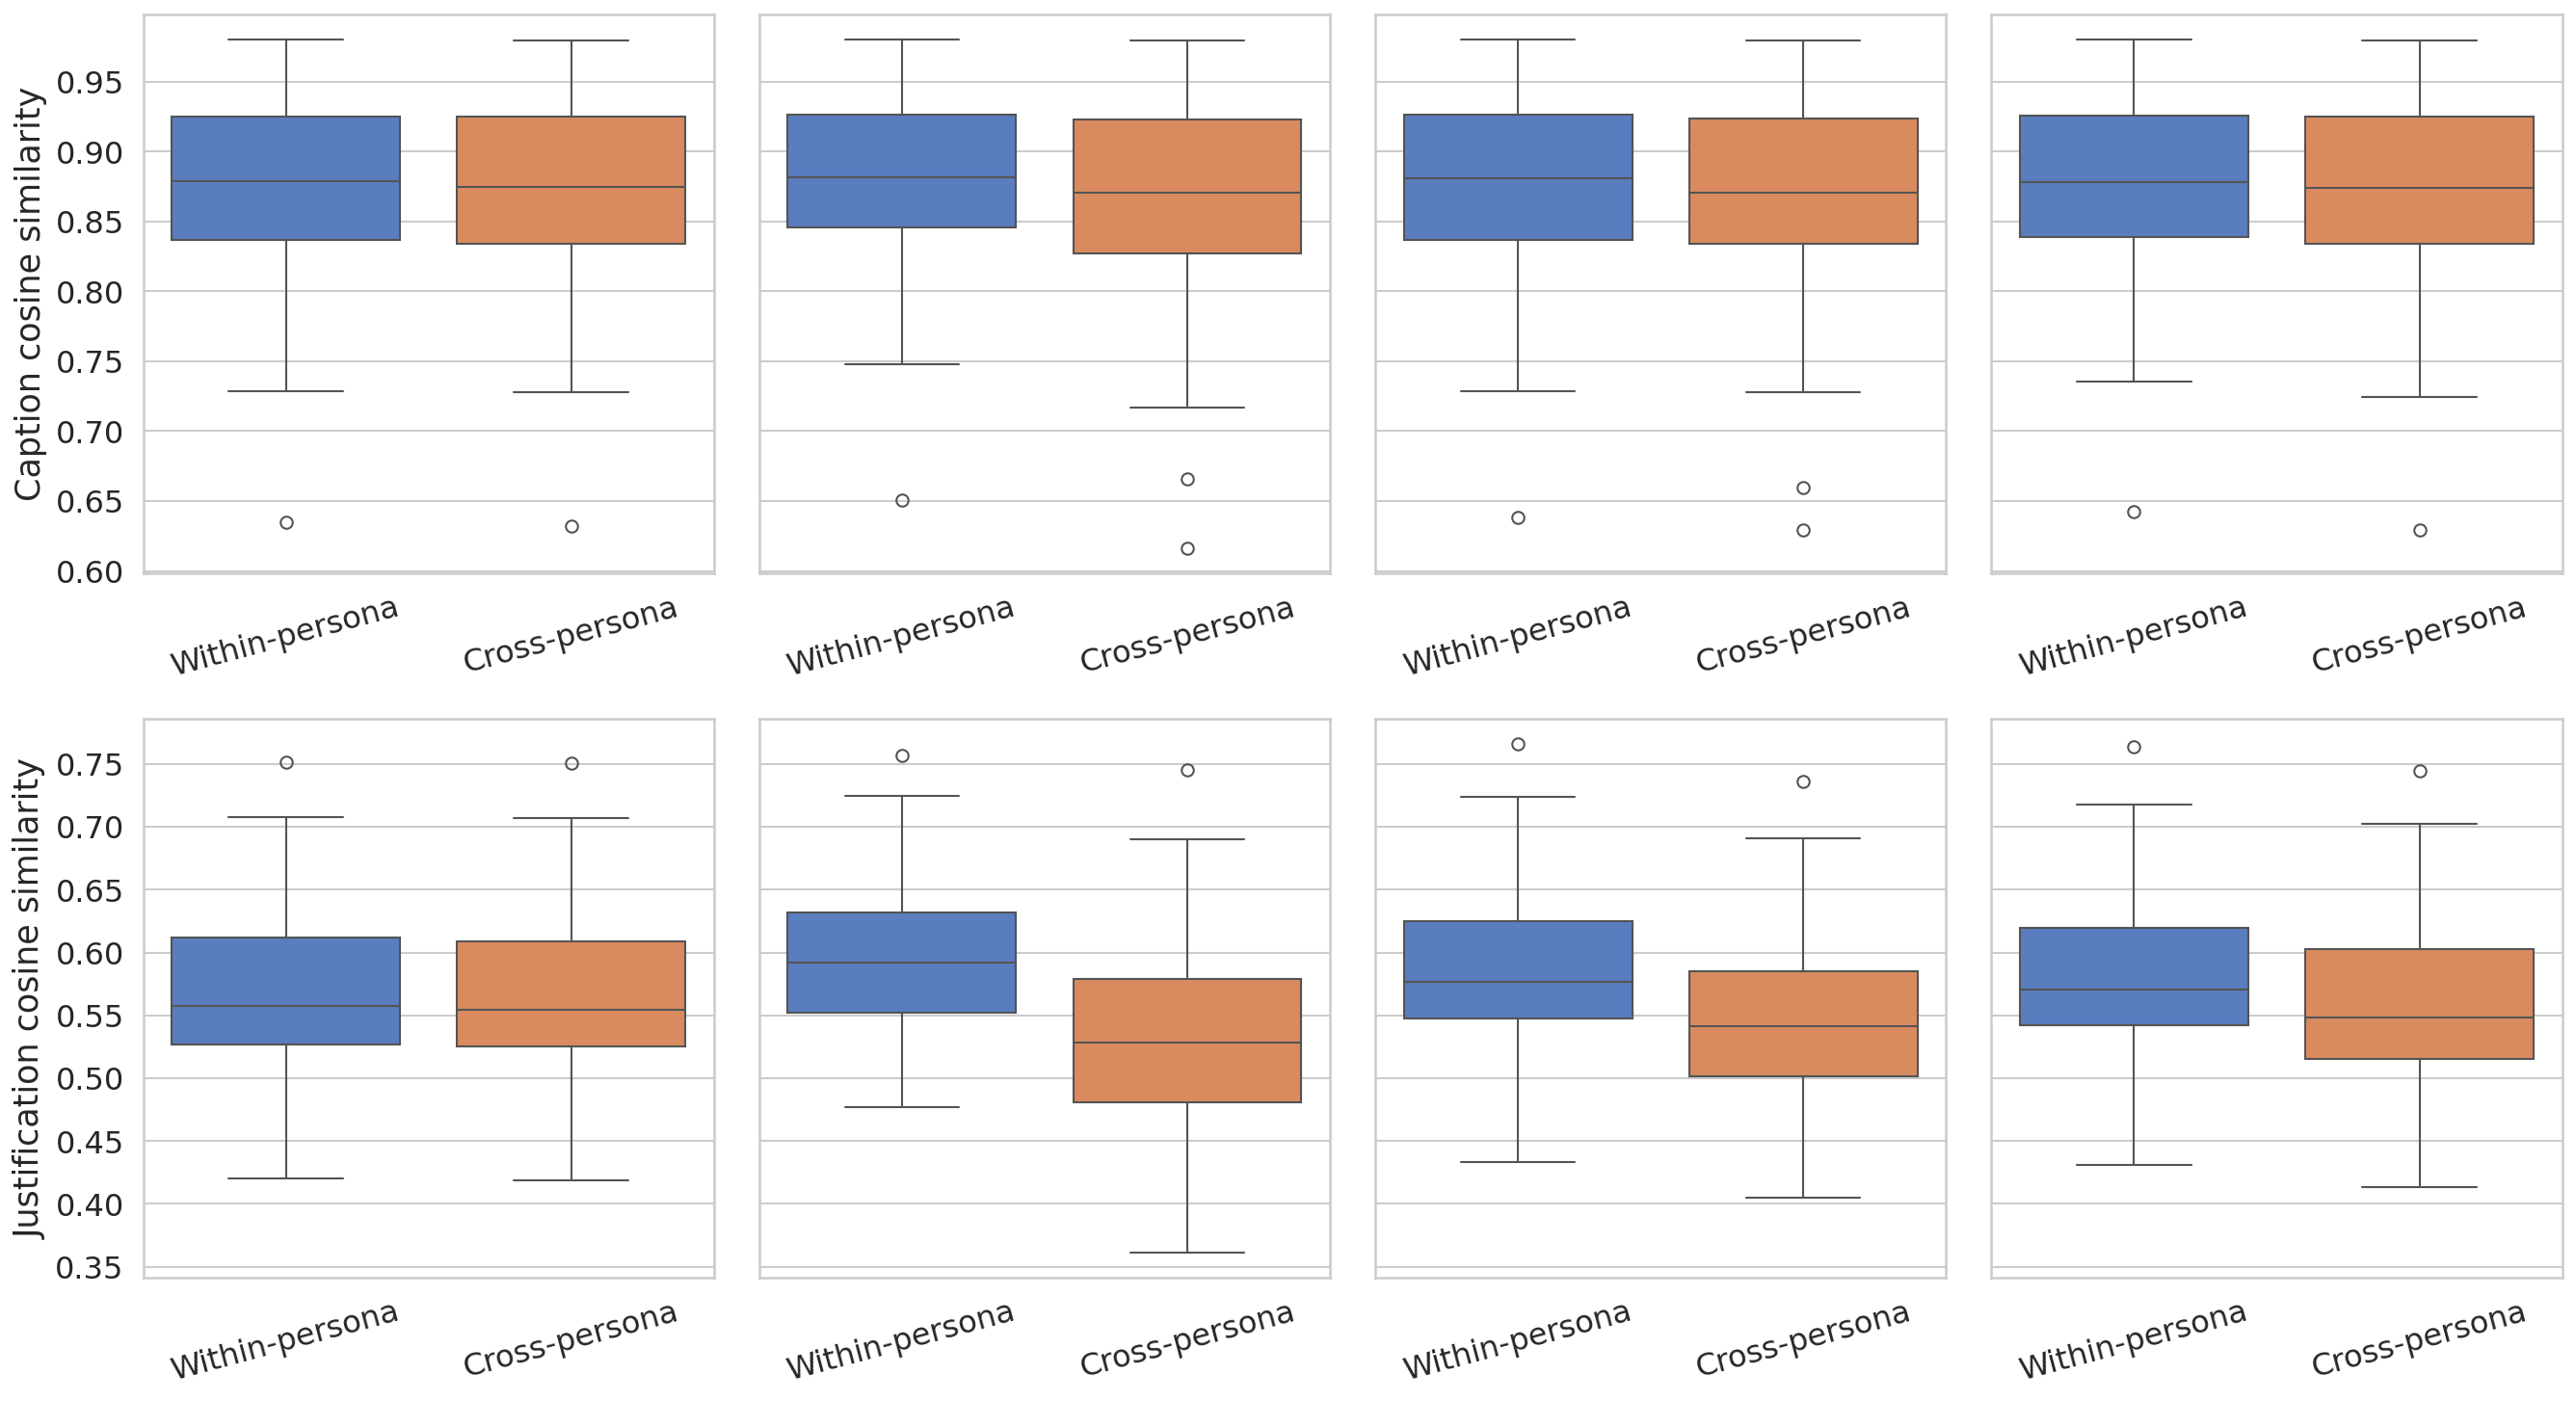


Modality        Dimension                 Within     Cross        Δ  p
────────────────────────────────────────────────────────────────────────
caption         Gender                    0.8736    0.8719  +0.0017  ns
caption         Economic status           0.8797    0.8658  +0.0138  ns
caption         Political spectrum        0.8763    0.8692  +0.0072  ns
caption         Personality               0.8749    0.8717  +0.0032  ns
justification   Gender                    0.5649    0.5628  +0.0021  ns
justification   Economic status           0.5947    0.5331  +0.0617  ***
justification   Political spectrum        0.5861    0.5417  +0.0444  ***
justification   Personality               0.5789    0.5564  +0.0225  ns


In [7]:
from scipy.stats import mannwhitneyu, wilcoxon

DIM_LABELS = {
    "gender":             "Gender",
    "economic_status":    "Economic status",
    "political_spectrum": "Political spectrum",
    "personality":        "Personality",
}

fig, axes = plt.subplots(2, 4, figsize=(18, 10), sharey="row")

for row_i, modality in enumerate(["caption", "justification"]):
    mod_df = wc_df[wc_df["modality"] == modality]

    for col_i, dim in enumerate(demo_cols):
        ax = axes[row_i][col_i]
        sub = mod_df[mod_df["dimension"] == dim].dropna(subset=["within_mean", "cross_mean"])

        within_vals = sub["within_mean"].values
        cross_vals  = sub["cross_mean"].values

        data_plot = pd.DataFrame({
            "similarity": np.concatenate([within_vals, cross_vals]),
            "group": ["Within-persona"] * len(within_vals) + ["Cross-persona"] * len(cross_vals),
        })
        palette = {"Within-persona": MUTED[0], "Cross-persona": MUTED[1]}
        sns.boxplot(data=data_plot, x="group", y="similarity", hue="group",
                    palette=palette, legend=False, ax=ax,
                    order=["Within-persona", "Cross-persona"])

        # Mann-Whitney U test
        stat, p = mannwhitneyu(within_vals, cross_vals, alternative="two-sided")
        sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
#         ax.set_title(f"{DIM_LABELS[dim]}
# (U={stat:.0f}, {sig})", fontsize=10)
        ax.set_xlabel("")
        ax.set_ylabel("Cosine similarity" if col_i == 0 else "")
        ax.tick_params(axis="x", rotation=15)

    axes[row_i][0].set_ylabel(
        f"{'Caption' if row_i == 0 else 'Justification'} cosine similarity"
    )

# fig.suptitle(
#     "Within-persona vs. cross-persona text similarity\n"
#     "by demographic dimension (per-image distributions)",
#     fontsize=13,
# )
plt.tight_layout()
fig.savefig(FIGURES / "fig_within_cross_persona_sim.pdf", bbox_inches="tight")
fig.savefig(FIGURES / "fig_within_cross_persona_sim.png", bbox_inches="tight")
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────
print(f"\n{'Modality':14s}  {'Dimension':22s}  {'Within':>8s}  {'Cross':>8s}  {'Δ':>7s}  p")
print("─" * 72)
for modality in ["caption", "justification"]:
    for dim in demo_cols:
        sub = wc_df[(wc_df["modality"] == modality) & (wc_df["dimension"] == dim)].dropna(
            subset=["within_mean", "cross_mean"])
        w  = sub["within_mean"].mean()
        c  = sub["cross_mean"].mean()
        stat, p = mannwhitneyu(sub["within_mean"].values, sub["cross_mean"].values, alternative="two-sided")
        sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
        print(f"{modality:14s}  {DIM_LABELS[dim]:22s}  {w:8.4f}  {c:8.4f}  {w-c:+7.4f}  {sig}")


## 11 · Within-persona profile coherence

**Research question**: Are agents assigned the same demographic profile (one of 24 profiles) coherent among themselves?

For each of the 24 full persona profiles we compute the mean pairwise cosine similarity
of (a) captions and (b) justifications across all 50 agents that share that profile.
We also compute pairwise Jaccard similarity of perception tag sets.
A high within-profile similarity means agents with the same persona speak consistently;
low similarity reveals intra-persona divergence.


In [8]:
WITHIN_PROFILE_CACHE = OUTPUTS / "within_profile_coherence.csv"

wp_df = compute_profile_coherence(df, cap_embs, just_embs, cap_idx, WITHIN_PROFILE_CACHE)
print(f"Profile coherence computed for {len(wp_df)} profiles")
wp_df.head()

Profile coherence computed for 24 profiles


,profile,n_agents,caption_coherence,justification_coherence,perception_jaccard
0,Female / High income / Conservative / Analytical,2495,0.233825,0.272050,0.500000
1,Female / High income / Conservative / Empathetic,2481,0.236403,0.252543,0.500000
2,Female / High income / Conservative / Pragmatic,2489,0.233555,0.261706,0.416667
3,Female / High income / Progressive / Analytical,2490,0.235881,0.280989,0.500000
4,Female / High income / Progressive / Empathetic,2488,0.232999,0.295695,0.500000


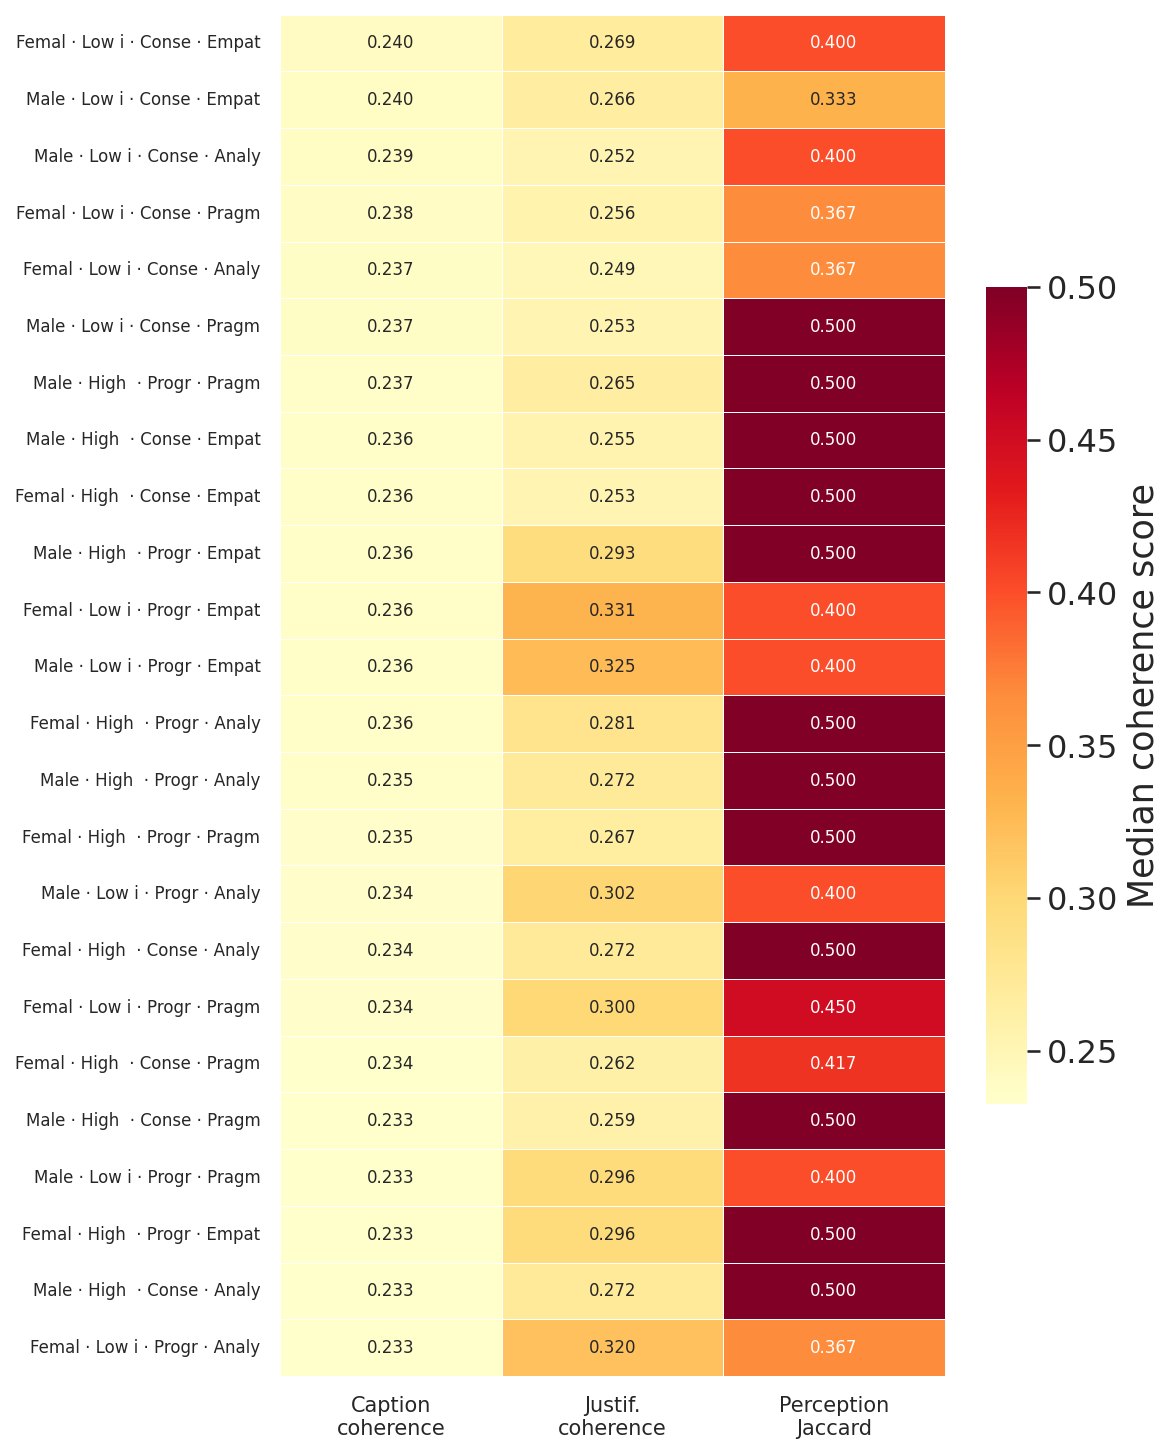

Saved fig_within_profile_coherence_heatmap


In [9]:
wp_sorted = wp_df.sort_values("caption_coherence", ascending=False).copy()
wp_sorted["short_label"] = wp_sorted["profile"].apply(
    lambda p: " · ".join(x.strip()[:5] for x in p.split("/"))
)

hm_data = wp_sorted.set_index("short_label")[
    ["caption_coherence", "justification_coherence", "perception_jaccard"]
]
hm_data.columns = ["Caption\ncoherence", "Justif.\ncoherence", "Perception\nJaccard"]

sns.set_theme(font_scale=1.4)
fig, ax = plt.subplots(figsize=(8, 10))
sns.heatmap(
    hm_data, ax=ax, cmap="YlOrRd", annot=True, fmt=".3f",
    linewidths=0.4, linecolor="white",
    cbar_kws={"label": "Median coherence score", "shrink": 0.6},
    annot_kws={"size": 8},
)
ax.set_ylabel("")
ax.tick_params(axis="y", labelsize=8)
ax.tick_params(axis="x", labelsize=10)
plt.tight_layout()
fig.savefig(FIGURES / "fig_within_profile_coherence_heatmap.pdf", bbox_inches="tight")
fig.savefig(FIGURES / "fig_within_profile_coherence_heatmap.png", bbox_inches="tight")
plt.show()
print("Saved fig_within_profile_coherence_heatmap")